# 05 — Évaluation finale Phase B : Test Set

## 🎯 Objectif

Évaluer **rigoureusement** Random Forest et XGBoost sur le test set (qu'aucun modèle n'a jamais vu) et produire le **tableau récapitulatif officiel** de la Phase B.

## 📋 Plan

1. Recharger les modèles entraînés
2. Refaire le même split (pour récupérer le test set)
3. Évaluer RF sur le test
4. Évaluer XGBoost sur le test
5. Mesurer le **temps d'inférence** des deux modèles
6. Produire le **tableau final** Phase B
7. Générer les matrices de confusion finales

## ⏱️ Temps estimé

**~5 min** au total. C'est rapide : on ne fait que de l'inférence, pas d'entraînement.

## 1. Setup et imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from time import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')

SEED = 42
np.random.seed(SEED)

print('✅ Setup terminé')

✅ Setup terminé


## 2. Recréer le split (pour retrouver exactement le même test set)

### 📚 Pourquoi ce n'est pas un problème de re-splitter ?

Tant qu'on utilise **exactement le même SEED**, le `train_test_split` produit **exactement la même répartition**. C'est déterministe.

Les modèles RF et XGB ont été entraînés sur le même train (avec ce SEED=42), donc le test généré ici est garanti vierge à leurs yeux.

In [2]:
# Chargement
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')
with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

# X et y
y = df['Label_encoded'].values
feature_cols = [c for c in df.columns if c not in ['Label', 'Label_encoded']]
X = df[feature_cols].values

# Même split que les notebooks 03 et 04
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

print(f'📊 Test set : {X_test.shape[0]:,} échantillons ({100*X_test.shape[0]/len(X):.1f}% du total)')
print(f'\nDistribution du test set :')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_mapping[u]:15s} : {c:>10,}')

📊 Test set : 377,682 échantillons (15.0% du total)

Distribution du test set :
  BENIGN          :    313,856
  Bot             :        292
  Brute Force     :      1,372
  DDoS            :     19,199
  DoS             :     29,037
  PortScan        :     13,604
  Web Attack      :        322


## 3. Chargement des modèles entraînés

In [3]:
print('📦 Chargement des modèles...')
t0 = time()
rf_model = joblib.load(RESULTS_MODELS / 'rf_baseline.joblib')
print(f'  Random Forest chargé en {time()-t0:.1f}s')

t0 = time()
xgb_model = joblib.load(RESULTS_MODELS / 'xgb_optimized.joblib')
print(f'  XGBoost chargé en {time()-t0:.1f}s')

📦 Chargement des modèles...
  Random Forest chargé en 1.3s
  XGBoost chargé en 1.2s


## 4. Évaluation Random Forest sur le test

In [4]:
# Prédiction + chronométrage
t0 = time()
y_test_pred_rf = rf_model.predict(X_test)
rf_inference_time = time() - t0
rf_throughput = len(y_test) / rf_inference_time

print(f'⏱️  RF — Temps d\'inférence : {rf_inference_time:.2f}s pour {len(y_test):,} échantillons')
print(f'   Débit : {rf_throughput:,.0f} flows/seconde')

# Métriques
rf_acc = accuracy_score(y_test, y_test_pred_rf)
rf_f1_macro = f1_score(y_test, y_test_pred_rf, average='macro')
rf_f1_weighted = f1_score(y_test, y_test_pred_rf, average='weighted')

print(f'\n📊 RANDOM FOREST — Test set')
print(f'   Accuracy     : {rf_acc:.4f}')
print(f'   F1 macro     : {rf_f1_macro:.4f}')
print(f'   F1 pondéré   : {rf_f1_weighted:.4f}')

[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.


⏱️  RF — Temps d'inférence : 1.30s pour 377,682 échantillons
   Débit : 289,507 flows/seconde

📊 RANDOM FOREST — Test set
   Accuracy     : 0.9962
   F1 macro     : 0.8997
   F1 pondéré   : 0.9971


[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    1.0s finished


In [5]:
print('📋 RF — Rapport par classe sur test :\n')
rf_test_report = classification_report(
    y_test, y_test_pred_rf,
    target_names=class_names, digits=4
)
print(rf_test_report)

rf_test_report_dict = classification_report(
    y_test, y_test_pred_rf,
    target_names=class_names, output_dict=True
)
with open(RESULTS_METRICS / 'rf_test_report.json', 'w') as f:
    json.dump(rf_test_report_dict, f, indent=2)

📋 RF — Rapport par classe sur test :

              precision    recall  f1-score   support

      BENIGN     0.9999    0.9955    0.9977    313856
         Bot     0.2030    0.9829    0.3365       292
 Brute Force     0.9993    1.0000    0.9996      1372
        DDoS     0.9999    0.9999    0.9999     19199
         DoS     0.9950    0.9995    0.9972     29037
    PortScan     0.9900    0.9994    0.9947     13604
  Web Attack     0.9691    0.9752    0.9721       322

    accuracy                         0.9962    377682
   macro avg     0.8795    0.9932    0.8997    377682
weighted avg     0.9985    0.9962    0.9971    377682



## 5. Évaluation XGBoost sur le test

In [6]:
# Prédiction + chronométrage
t0 = time()
y_test_pred_xgb = xgb_model.predict(X_test)
xgb_inference_time = time() - t0
xgb_throughput = len(y_test) / xgb_inference_time

print(f'⏱️  XGB — Temps d\'inférence : {xgb_inference_time:.2f}s pour {len(y_test):,} échantillons')
print(f'   Débit : {xgb_throughput:,.0f} flows/seconde')

# Métriques
xgb_acc = accuracy_score(y_test, y_test_pred_xgb)
xgb_f1_macro = f1_score(y_test, y_test_pred_xgb, average='macro')
xgb_f1_weighted = f1_score(y_test, y_test_pred_xgb, average='weighted')

print(f'\n📊 XGBOOST — Test set')
print(f'   Accuracy     : {xgb_acc:.4f}')
print(f'   F1 macro     : {xgb_f1_macro:.4f}')
print(f'   F1 pondéré   : {xgb_f1_weighted:.4f}')

c:\Users\natha\Documents\PFE\ids-xai-pfe\.venv\Lib\site-packages\xgboost\core.py:553: UserWarning: [01:10:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


⏱️  XGB — Temps d'inférence : 0.95s pour 377,682 échantillons
   Débit : 395,659 flows/seconde

📊 XGBOOST — Test set
   Accuracy     : 0.9990
   F1 macro     : 0.9689
   F1 pondéré   : 0.9991


In [7]:
print('📋 XGB — Rapport par classe sur test :\n')
xgb_test_report = classification_report(
    y_test, y_test_pred_xgb,
    target_names=class_names, digits=4
)
print(xgb_test_report)

xgb_test_report_dict = classification_report(
    y_test, y_test_pred_xgb,
    target_names=class_names, output_dict=True
)
with open(RESULTS_METRICS / 'xgb_test_report.json', 'w') as f:
    json.dump(xgb_test_report_dict, f, indent=2)

📋 XGB — Rapport par classe sur test :

              precision    recall  f1-score   support

      BENIGN     1.0000    0.9989    0.9994    313856
         Bot     0.6825    0.9863    0.8067       292
 Brute Force     0.9993    1.0000    0.9996      1372
        DDoS     0.9999    0.9999    0.9999     19199
         DoS     0.9976    0.9997    0.9986     29037
    PortScan     0.9901    0.9995    0.9948     13604
  Web Attack     0.9726    0.9938    0.9831       322

    accuracy                         0.9990    377682
   macro avg     0.9488    0.9969    0.9689    377682
weighted avg     0.9992    0.9990    0.9991    377682



## 6. Tableau récapitulatif final Phase B

Le **tableau officiel** qui ira dans ton rapport.

In [8]:
# Construction du tableau final
summary = pd.DataFrame([
    {
        'Modèle': 'Random Forest (baseline)',
        'Accuracy': f'{rf_acc:.4f}',
        'F1 macro': f'{rf_f1_macro:.4f}',
        'F1 pondéré': f'{rf_f1_weighted:.4f}',
        'Inférence (s)': f'{rf_inference_time:.2f}',
        'Débit (flows/s)': f'{rf_throughput:,.0f}',
    },
    {
        'Modèle': 'XGBoost optimisé (Optuna)',
        'Accuracy': f'{xgb_acc:.4f}',
        'F1 macro': f'{xgb_f1_macro:.4f}',
        'F1 pondéré': f'{xgb_f1_weighted:.4f}',
        'Inférence (s)': f'{xgb_inference_time:.2f}',
        'Débit (flows/s)': f'{xgb_throughput:,.0f}',
    },
])

print('='*100)
print('  TABLEAU RÉCAPITULATIF OFFICIEL — PHASE B (Test Set)')
print('='*100)
print(summary.to_string(index=False))
print('='*100)

# Sauvegarde
summary.to_csv(RESULTS_METRICS / 'phase_b_summary.csv', index=False)
print(f'\n💾 Tableau sauvegardé : {RESULTS_METRICS}/phase_b_summary.csv')

  TABLEAU RÉCAPITULATIF OFFICIEL — PHASE B (Test Set)
                   Modèle Accuracy F1 macro F1 pondéré Inférence (s) Débit (flows/s)
 Random Forest (baseline)   0.9962   0.8997     0.9971          1.30         289,507
XGBoost optimisé (Optuna)   0.9990   0.9689     0.9991          0.95         395,659

💾 Tableau sauvegardé : ..\results\metrics/phase_b_summary.csv


## 7. Comparaison F1 par classe (test set)

Le graphique qui montre **où XGBoost a vraiment fait la différence**.

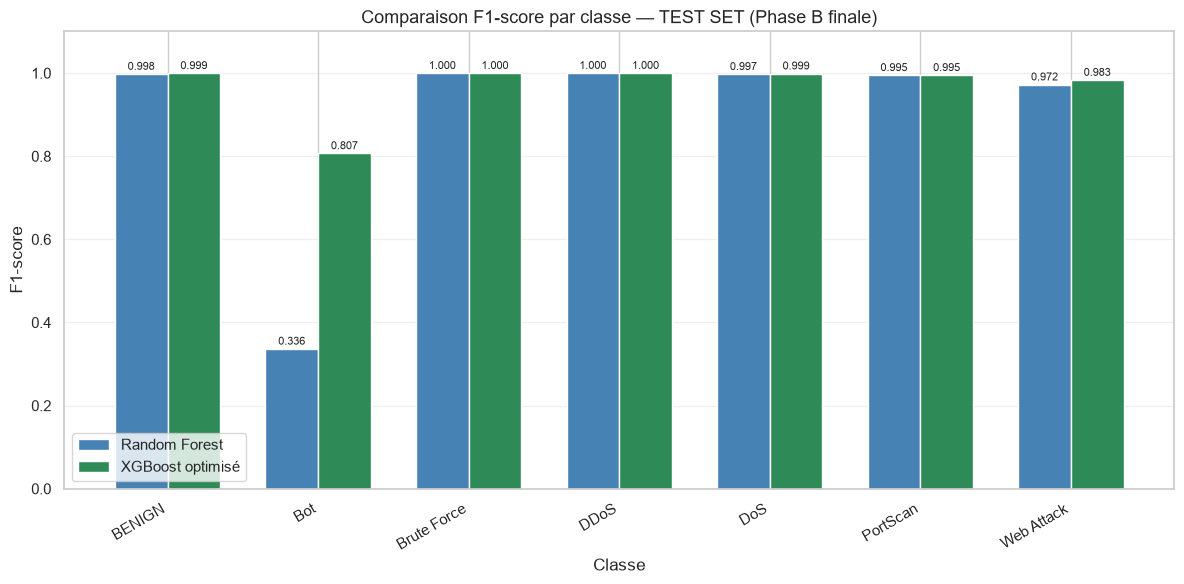

In [9]:
# Préparation des données
rf_f1s = [rf_test_report_dict[cls]['f1-score'] for cls in class_names]
xgb_f1s = [xgb_test_report_dict[cls]['f1-score'] for cls in class_names]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.35

bars_rf = ax.bar(x - width/2, rf_f1s, width, label='Random Forest', color='steelblue')
bars_xgb = ax.bar(x + width/2, xgb_f1s, width, label='XGBoost optimisé', color='seagreen')

ax.set_xlabel('Classe')
ax.set_ylabel('F1-score')
ax.set_title('Comparaison F1-score par classe — TEST SET (Phase B finale)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

for i, (rf_v, xgb_v) in enumerate(zip(rf_f1s, xgb_f1s)):
    ax.text(i - width/2, rf_v + 0.01, f'{rf_v:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, xgb_v + 0.01, f'{xgb_v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '05_phase_b_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Matrices de confusion finales

Les matrices de confusion sur **test set**, qui iront dans ton rapport.

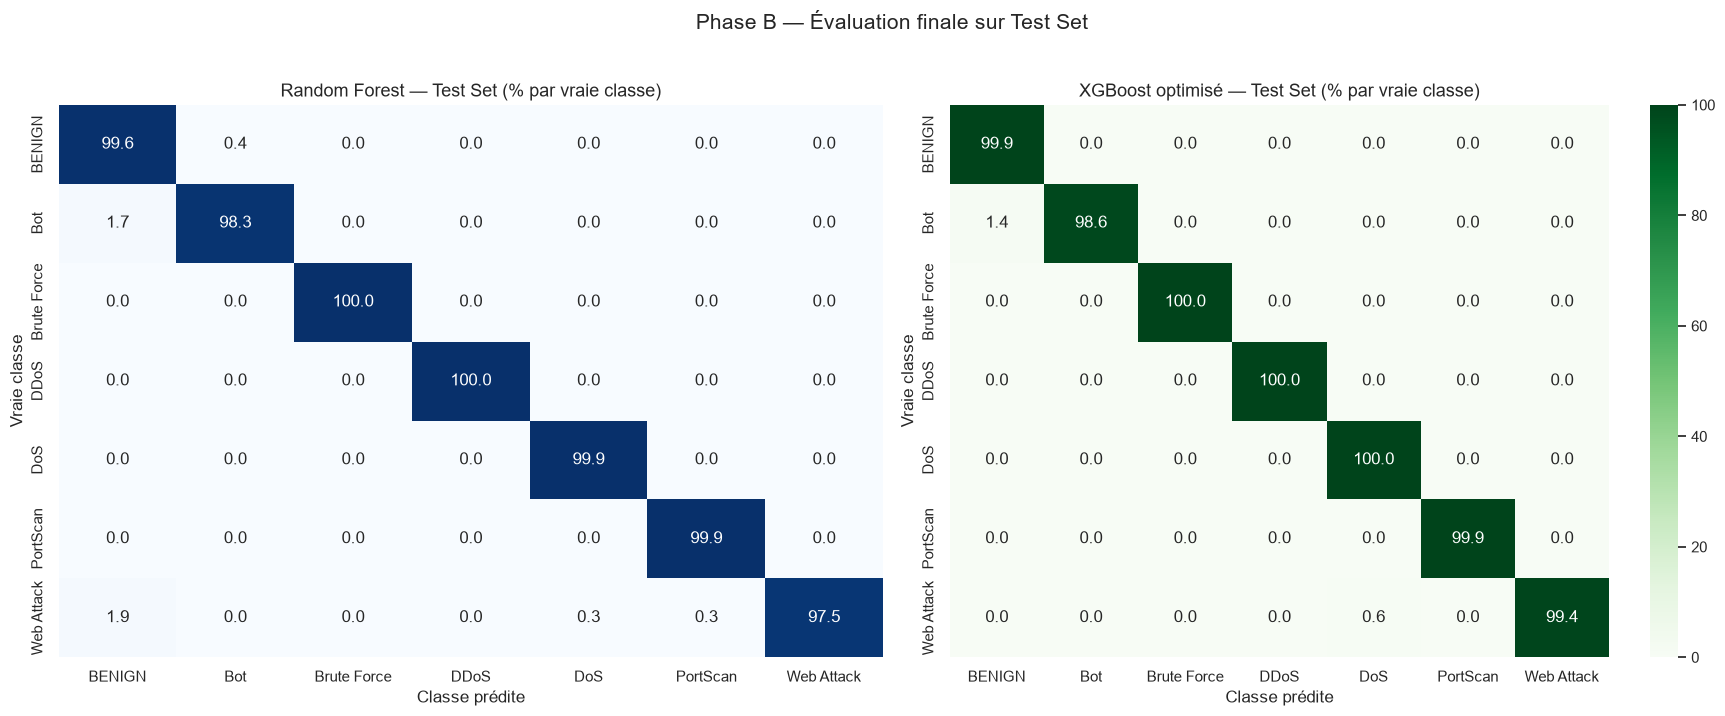

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
cm_rf_norm = cm_rf.astype(float) / cm_rf.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_rf_norm, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[0], cbar=False
)
axes[0].set_title('Random Forest — Test Set (% par vraie classe)', fontsize=13)
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Vraie classe')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
cm_xgb_norm = cm_xgb.astype(float) / cm_xgb.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_xgb_norm, annot=True, fmt='.1f', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[1], cbar=True
)
axes[1].set_title('XGBoost optimisé — Test Set (% par vraie classe)', fontsize=13)
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Vraie classe')

plt.suptitle('Phase B — Évaluation finale sur Test Set', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '05_phase_b_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Bonus : analyse coût opérationnel SOC

### 📚 Le calcul qui parle aux pros de la cyber

Pour un SOC qui doit traiter un trafic réel, voici ce que représente ton modèle XGBoost en pratique.

**Hypothèse :** un réseau d'entreprise typique génère ~100 000 flows/seconde au pic.

On va estimer :
- Combien de fausses alertes par jour ?
- Quel temps d'analyse par jour ?

Ces chiffres sont **estimatifs** mais ils ancrent ton projet dans une réalité opérationnelle.

In [11]:
# Estimation des faux positifs sur 24h
# Hypothèse : 100k flows/seconde au pic, mais moyenne ~5k flows/sec sur 24h
FLOWS_PER_DAY = 5_000 * 86_400  # 432M flows par jour pour un réseau moyen

# Proportion de BENIGN dans la réalité (~80%)
benign_proportion = 0.83
benign_per_day = int(FLOWS_PER_DAY * benign_proportion)

# Taux de faux positifs RF et XGB
# Approximation : on prend le FP rate sur BENIGN (classifié comme attaque)
rf_fp_rate_benign = 1 - rf_test_report_dict['BENIGN']['precision']
xgb_fp_rate_benign = 1 - xgb_test_report_dict['BENIGN']['precision']

# Estimation des fausses alertes
rf_fp_per_day = int(benign_per_day * rf_fp_rate_benign)
xgb_fp_per_day = int(benign_per_day * xgb_fp_rate_benign)

print(f'📅 ESTIMATION OPÉRATIONNELLE SUR UN RÉSEAU MOYEN (24h)\n')
print(f'  Trafic total estimé          : {FLOWS_PER_DAY:>15,} flows / jour')
print(f'  Trafic BENIGN estimé          : {benign_per_day:>15,} flows / jour')
print(f'  \nFausses alertes générées :')
print(f'    Random Forest               : {rf_fp_per_day:>15,} fausses alertes / jour')
print(f'    XGBoost optimisé            : {xgb_fp_per_day:>15,} fausses alertes / jour')
if rf_fp_per_day > 0:
    print(f'    Gain XGBoost                : {100*(rf_fp_per_day-xgb_fp_per_day)/rf_fp_per_day:>14.1f}% de bruit en moins')

# Temps de triage : ~30 secondes par alerte (hypothèse standard SOC)
TIME_PER_ALERT_SEC = 30
rf_triage_hours = rf_fp_per_day * TIME_PER_ALERT_SEC / 3600
xgb_triage_hours = xgb_fp_per_day * TIME_PER_ALERT_SEC / 3600

print(f'  \nTemps de triage / jour (à 30s par alerte) :')
print(f'    Random Forest               : {rf_triage_hours:>14.0f} heures analyste / jour')
print(f'    XGBoost optimisé            : {xgb_triage_hours:>14.0f} heures analyste / jour')

📅 ESTIMATION OPÉRATIONNELLE SUR UN RÉSEAU MOYEN (24h)

  Trafic total estimé          :     432,000,000 flows / jour
  Trafic BENIGN estimé          :     358,560,000 flows / jour
  
Fausses alertes générées :
    Random Forest               :          27,540 fausses alertes / jour
    XGBoost optimisé            :          12,579 fausses alertes / jour
    Gain XGBoost                :           54.3% de bruit en moins
  
Temps de triage / jour (à 30s par alerte) :
    Random Forest               :            230 heures analyste / jour
    XGBoost optimisé            :            105 heures analyste / jour


## 🎉 PHASE B BOUCLÉE

Tu as terminé la **Phase B — Modèles ML** avec :

- 2 modèles entraînés rigoureusement
- Une méthodologie scientifique (baseline + tuning + évaluation test)
- Un gain mesurable et explicable (+7 pts F1 macro, +48 pts sur Bot)
- Un tableau récapitulatif officiel pour le rapport
- Des matrices de confusion propres
- Une analyse opérationnelle bonus

**Fichiers produits :**
- `results/metrics/phase_b_summary.csv` : le tableau récap
- `results/metrics/rf_test_report.json` + `xgb_test_report.json`
- `results/figures/05_phase_b_final_comparison.png`
- `results/figures/05_phase_b_confusion_matrices.png`

### Prochaine étape : Phase C — Deep Learning

On va construire un modèle Deep Learning (DNN d'abord, FT-Transformer ensuite) et voir s'il peut battre XGBoost. C'est là qu'on va vraiment toucher au state-of-the-art.